# Классификация автоматизированного трафика

Тестовое задание на стажировку Avito. Выполнила Кушнир Анна

Задача: оценить для каждой куки вероятность того, что ее действия относятся к автоматизированному сбору данных.
Из событий только внутри заданного суточного окна строится 141 признак: частоты действий, разнообразие просмотренных объявений и запросов, интервалы между событиями, движения курсора и общие характеристики клиента. Затем обучается CatBoostClassifier, который выдаёт score от 0 до 1.
Качество проверяется на более поздних днях обучающей выборки официальной метрикой Precision при Recall ≥ 70%.

На локальной проверке получены 0,7733 и 0,8370.

In [1]:
import sys
import subprocess

print("Python:", sys.version)

if sys.version_info[:2] == (3, 12):
    packages = [
        "numpy==1.26.4",
        "pandas==2.2.2",
        "scikit-learn==1.4.2",
        "catboost==1.2.10",
    ]
else:
    packages = ["catboost==1.2.10"]

subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "--only-binary=:all:", *packages
])
print("Установка завершена")

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Установка завершена


In [2]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')
PROJECT = Path('/content/drive/MyDrive/bot_detection_challenge')
for name in ['data/train.csv', 'data/test.csv', 'data/events.csv.gz']:
    path = PROJECT / name
    assert path.is_file(), f'Не найден файл: {path}'
    print('OK:', path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OK: /content/drive/MyDrive/bot_detection_challenge/data/train.csv
OK: /content/drive/MyDrive/bot_detection_challenge/data/test.csv
OK: /content/drive/MyDrive/bot_detection_challenge/data/events.csv.gz


импортируем библиотеки, фиксируем SEED=42 для воспроизводимости и задаем список типов событий. загружаем train, test и сжатый файл событий

In [3]:
import warnings
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier

SEED = 42
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)
EVENTS = [
    'search_results_view', 'item_view', 'photo_swipe', 'seller_page_view',
    'contact_phone_show', 'contact_chat_open', 'contact_message_sent',
    'favorite_add', 'login', 'captcha_shown',
]

train = pd.read_csv(PROJECT / 'data/train.csv')
test = pd.read_csv(PROJECT / 'data/test.csv')
events = pd.read_csv(PROJECT / 'data/events.csv.gz', parse_dates=['event_ts'])
print('train:', train.shape, 'test:', test.shape, 'events:', events.shape)
print('Ботов в train:', int(train.target.sum()))

train: (11091, 5) test: (4909, 4) events: (328905, 14)
Ботов в train: 899


#### Визуализация данных

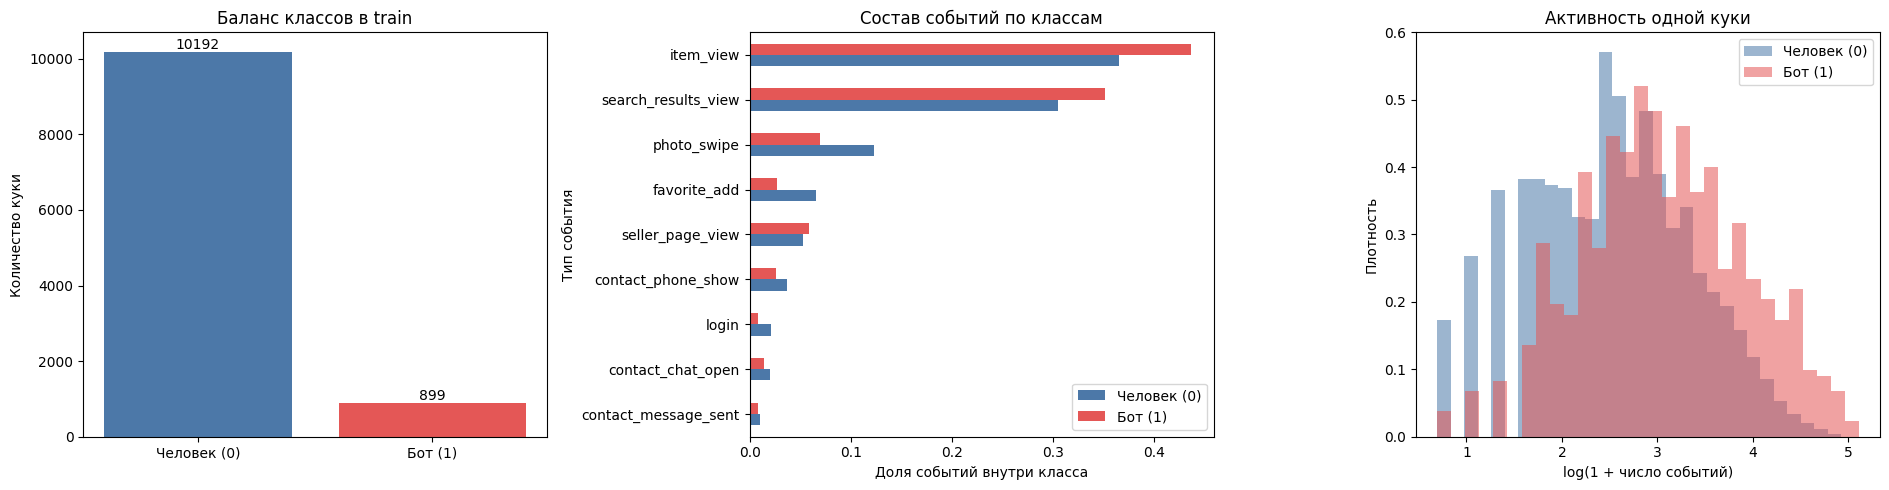

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Метки и границы окна для обучающих куки
meta_eda = train[
    ["cookie_id", "target", "window_start_ts", "window_end_ts"]
].copy()
meta_eda["window_start_ts"] = pd.to_datetime(meta_eda["window_start_ts"])
meta_eda["window_end_ts"] = pd.to_datetime(meta_eda["window_end_ts"])

# Берем только события train внутри соответствующего суточного окна
events_eda = events.merge(meta_eda, on="cookie_id", how="inner")
events_eda = events_eda.loc[
    (events_eda["event_ts"] >= events_eda["window_start_ts"])
    & (events_eda["event_ts"] < events_eda["window_end_ts"])
].copy()

# Полностью одинаковые записи событий учитываем один раз
events_eda = events_eda.drop_duplicates(
    subset=events.columns.tolist()
).copy()

# Число событий для каждой куки, включая куки без событий
cookie_counts = (
    events_eda.groupby("cookie_id")
    .size()
    .reindex(train["cookie_id"], fill_value=0)
    .to_numpy()
)
cookie_eda = train[["target"]].copy()
cookie_eda["n_events"] = cookie_counts

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# Баланс классов по куки
class_counts = train["target"].value_counts().reindex([0, 1], fill_value=0)

axes[0].bar(
    ["Человек (0)", "Бот (1)"],
    class_counts.values,
    color=["#4C78A8", "#E45756"],
)
axes[0].set_title("Баланс классов в train")
axes[0].set_ylabel("Количество куки")

for i, count in enumerate(class_counts.values):
    axes[0].text(i, count, str(count), ha="center", va="bottom")

# Доля каждого типа событий внутри класса
event_shares = pd.crosstab(
    events_eda["event_name"],
    events_eda["target"],
    normalize="columns",
).reindex(columns=[0, 1], fill_value=0)

event_shares.columns = ["Человек (0)", "Бот (1)"]
event_shares.sort_values("Человек (0)").plot.barh(
    ax=axes[1],
    color=["#4C78A8", "#E45756"],
)
axes[1].set_title("Состав событий по классам")
axes[1].set_xlabel("Доля событий внутри класса")
axes[1].set_ylabel("Тип события")

# Распределение числа событий на одну куки
for target, label, color in [
    (0, "Человек (0)", "#4C78A8"),
    (1, "Бот (1)", "#E45756"),
]:
    values = np.log1p(
        cookie_eda.loc[cookie_eda["target"] == target, "n_events"]
    )
    axes[2].hist(
        values,
        bins=30,
        density=True,
        alpha=0.55,
        label=label,
        color=color,
    )

axes[2].set_title("Активность одной куки")
axes[2].set_xlabel("log(1 + число событий)")
axes[2].set_ylabel("Плотность")
axes[2].legend()

plt.tight_layout()
plt.show()

В обучающей выборке ботов значительно меньше, чем людей: 899 против 10 192 (около 8%). Поэтому при оценке модели важно учитывать, сколько ботов она находит и как часто ошибочно отмечает людей.
Состав событий различается: у ботов выше доля просмотров выдачи и объявлений, у людей - листания фотографий и добавления в избранное. Это доли событий, а не куки, поэтому по графику пока нельзя судить о поведении каждой отдельной куки.
Боты в среднем создают больше событий, но распределения активности сильно пересекаются. Одного количества событий, будет недостаточно; стоит дополнительно изучить последовательность действий, интервалы между ними и разнообразие просмотренного.

#### Официальная метрика

Код функций перенесён из `metric.py`. Куки с одинаковым score считаются одной группой.

In [5]:
TARGET_RECALL = 0.70

def pr_curve(y_true, score) -> tuple[np.ndarray, np.ndarray]:
    """(precision, recall) в точках на границах групп одинакового score."""
    y_true = np.asarray(y_true, dtype=int)
    score = np.asarray(score, dtype=float)
    if y_true.shape != score.shape:
        raise ValueError("y_true и score разной длины")

    n_pos = int(y_true.sum())
    if n_pos == 0:
        return np.array([]), np.array([])

    order = np.argsort(-score, kind="mergesort")
    y, s = y_true[order], score[order]

    tp = np.cumsum(y)
    k = np.arange(1, len(y) + 1)
    ends = np.r_[s[1:] != s[:-1], True]      # последняя строка каждой группы равных score
    return tp[ends] / k[ends], tp[ends] / n_pos

def precision_at_recall(y_true, score, recall: float = TARGET_RECALL) -> float:
    """Максимальный precision среди порогов с recall >= `recall`."""
    prec, rec = pr_curve(y_true, score)
    if len(prec) == 0:
        return float("nan")
    ok = rec >= recall
    return float(prec[ok].max()) if ok.any() else 0.0

assert precision_at_recall([1, 0, 1, 1, 1], [5, 4, 3, 2, 1]) == 0.8
print("Метрика готова")

Метрика готова


#### Вспомогательные функции для признаков

In [6]:
def dominant_share(values: pd.Series) -> pd.Series:
    """Largest within-cookie frequency divided by observed count."""
    return values.groupby(level=0).max() / values.groupby(level=0).sum()

def add_numeric_aggregates(out: pd.DataFrame, events: pd.DataFrame, column: str, prefix: str) -> None:
    grouped = events.groupby("cookie_id")[column]
    stats = grouped.agg(["mean", "std", "min", "max", "median", "nunique"])
    stats.columns = [f"{prefix}_{x}" for x in stats.columns]
    out[stats.columns] = stats

#### Построение признаков

Для каждой куки берутся только события внутри окна window_start_ts <= event_ts < window_end_ts; события после окончания окна недоступны в момент предсказания. Полностью одинаковые записи событий учитываются один раз. Пропуски описываются долями заполненных полей, а после расчёта числовых признаков оставшиеся отсутствующие значения заменяются на -1.

Признаки отражают разные стороны поведения: частоты действий и интервалы между ними - скорость автоматизации; разнообразие объявлений, категорий, локаций и запросов - широту обхода; курсор и последовательности действий - характер взаимодействия со страницей. Категориальные значения переводятся в частоты, число уникальных значений и долю наиболее частого значения; строки User-Agent не используются как уникальные идентификаторы.

In [7]:
def make_features(meta: pd.DataFrame, raw_events: pd.DataFrame) -> pd.DataFrame:
    meta = meta.copy().set_index("cookie_id", drop=True)
    for c in ["cookie_created_at", "window_start_ts", "window_end_ts"]:
        meta[c] = pd.to_datetime(meta[c])

    ev = raw_events.merge(meta[["window_start_ts", "window_end_ts"]],
                          left_on="cookie_id", right_index=True, how="inner")
    ev = ev[(ev.event_ts >= ev.window_start_ts) & (ev.event_ts < ev.window_end_ts)].copy()

    # Полностью одинаковые записи событий учитываем один раз
    ev.drop_duplicates(inplace=True)
    ev.sort_values(["cookie_id", "event_ts"], kind="stable", inplace=True)
    group = ev.groupby("cookie_id", sort=False)

    out = pd.DataFrame(index=meta.index)
    out["cookie_age_hours"] = (meta.window_end_ts - meta.cookie_created_at).dt.total_seconds() / 3600
    out["cookie_age_days_log"] = np.log1p(out.cookie_age_hours.clip(lower=0) / 24)
    out["created_before_window_hours"] = (meta.window_start_ts - meta.cookie_created_at).dt.total_seconds() / 3600
    out["created_during_window"] = ((meta.cookie_created_at >= meta.window_start_ts) &
                                    (meta.cookie_created_at < meta.window_end_ts)).astype(int)
    out["created_hour"] = meta.cookie_created_at.dt.hour
    out["created_weekday"] = meta.cookie_created_at.dt.dayofweek
    out["n_events"] = group.size()

    counts = pd.crosstab(ev.cookie_id, ev.event_name).reindex(columns=EVENTS, fill_value=0)
    for name in EVENTS:
        out[f"count_{name}"] = counts[name]
        out[f"share_{name}"] = counts[name] / out.n_events

    for col in ["item_id", "item_category", "item_location", "seller_type",
                "search_query", "search_page", "user_agent", "platform"]:
        out[f"nunique_{col}"] = group[col].nunique()
        out[f"filled_{col}"] = group[col].count() / out.n_events
        frequencies = ev.dropna(subset=[col]).groupby(["cookie_id", col]).size()
        if len(frequencies):
            out[f"dominant_{col}"] = dominant_share(frequencies)
        if col in ["item_id", "item_category", "item_location", "search_query"]:
            out[f"diversity_{col}"] = out[f"nunique_{col}"] / out.n_events

    for col in ["search_page", "pointer_x", "pointer_y"]:
        ev[col] = pd.to_numeric(ev[col], errors="coerce")
        add_numeric_aggregates(out, ev, col, col)
    out["pointer_present_rate"] = group.pointer_x.count() / out.n_events
    out["pointer_zero_rate"] = ev.pointer_x.eq(0).groupby(ev.cookie_id).sum() / out.n_events
    out["search_page_gt1_rate"] = ev.search_page.gt(1).groupby(ev.cookie_id).sum() / out.n_events

    out["first_event_hour"] = group.event_ts.min().dt.hour
    out["last_event_hour"] = group.event_ts.max().dt.hour
    out["active_span_sec"] = (group.event_ts.max() - group.event_ts.min()).dt.total_seconds()
    out["events_per_active_hour"] = out.n_events / (1 + out.active_span_sec / 3600)
    out["active_hours"] = ev.groupby("cookie_id").event_ts.apply(lambda x: x.dt.floor("h").nunique())
    out["active_minutes"] = ev.groupby("cookie_id").event_ts.apply(lambda x: x.dt.floor("min").nunique())
    out["active_hours_fraction"] = out.active_hours / 24
    out["events_per_active_minute"] = out.n_events / out.active_minutes
    out["night_share"] = ev.event_ts.dt.hour.between(0, 5).groupby(ev.cookie_id).mean()
    out["morning_share"] = ev.event_ts.dt.hour.between(6, 11).groupby(ev.cookie_id).mean()
    out["evening_share"] = ev.event_ts.dt.hour.between(18, 23).groupby(ev.cookie_id).mean()

    delta = group.event_ts.diff().dt.total_seconds()
    ev["delta_sec"] = delta
    add_numeric_aggregates(out, ev, "delta_sec", "delta_sec")
    quantiles = ev.groupby("cookie_id").delta_sec.quantile([0.1, 0.25, 0.75, 0.9]).unstack()
    quantiles.columns = [f"delta_q{int(q * 100)}" for q in quantiles.columns]
    out[quantiles.columns] = quantiles
    for limit in [0, 1, 3, 10, 30, 60, 300]:
        out[f"delta_le_{limit}_share"] = delta.le(limit).groupby(ev.cookie_id).sum() / (out.n_events - 1).clip(lower=1)
    out["delta_cv"] = out.delta_sec_std / (out.delta_sec_mean + 1e-6)
    for unit in ["s", "min", "h"]:
        bins = ev.event_ts.dt.floor(unit)
        bin_counts = ev.groupby([ev.cookie_id, bins]).size().groupby(level=0)
        out[f"max_events_per_{unit}"] = bin_counts.max()
        out[f"mean_events_per_{unit}"] = bin_counts.mean()

    prev_item = group.item_id.shift()
    prev_event = group.event_name.shift()
    out["consecutive_same_item_rate"] = ((ev.item_id == prev_item) & ev.item_id.notna()).groupby(ev.cookie_id).sum() / out.n_events
    out["consecutive_same_event_rate"] = (ev.event_name == prev_event).groupby(ev.cookie_id).sum() / out.n_events
    for first, second in [("search_results_view", "item_view"), ("item_view", "photo_swipe"),
                          ("item_view", "seller_page_view"), ("item_view", "contact_phone_show"),
                          ("item_view", "item_view"), ("search_results_view", "search_results_view")]:
        out[f"transition_{first}_to_{second}"] = ((prev_event == first) & (ev.event_name == second)).groupby(ev.cookie_id).sum()

    # Broad client attributes generalize to dates and devices unseen during training.
    ev["platform_clean"] = ev.platform.str.lower().replace({"desktop": "web", "iphone": "ios"})
    platform_counts = pd.crosstab(ev.cookie_id, ev.platform_clean)
    for col in ["web", "android", "ios"]:
        out[f"platform_{col}_share"] = platform_counts.get(col, 0) / out.n_events

    ua = group.user_agent.first().fillna("")
    for name, pattern in {
        "android": r"Android", "iphone": r"iPhone", "ipad": r"iPad",
        "windows": r"Windows", "mac": r"Macintosh", "linux": r"Linux",
        "chrome": r"Chrome/", "firefox": r"Firefox/", "safari": r"Safari/",
        "app": r"Avito|okhttp|Dalvik", "headless": r"Headless|bot|crawler|python|curl",
    }.items():
        out[f"ua_{name}"] = ua.str.contains(pattern, case=False, regex=True).astype(int)
    out["ua_length"] = ua.str.len()
    out["ua_chrome_major"] = pd.to_numeric(ua.str.extract(r"Chrome/(\d+)", expand=False), errors="coerce")

    for numerator, denominator in [
        ("count_item_view", "count_search_results_view"),
        ("count_contact_phone_show", "count_item_view"),
        ("count_favorite_add", "count_item_view"),
        ("count_photo_swipe", "count_item_view"),
        ("nunique_item_id", "count_item_view"),
        ("nunique_search_query", "count_search_results_view"),
    ]:
        out[f"ratio_{numerator}_per_{denominator}"] = out[numerator] / (out[denominator] + 1)

    out = out.replace([np.inf, -np.inf], np.nan).fillna(-1)
    return out.astype("float32")

Собираем таблицы признаков для train и test

In [8]:
all_meta = pd.concat([train.drop(columns='target'), test], ignore_index=True)
features = make_features(all_meta, events)
x_train = features.loc[train.cookie_id].reset_index(drop=True)
x_test = features.loc[test.cookie_id].reset_index(drop=True)
y = train.target.astype(int)

print('Признаки train:', x_train.shape)
print('Признаки test:', x_test.shape)
print("Событий внутри окон после удаления дубликатов:", int(features.n_events.sum()))
assert int(features.n_events.sum()) == 283833

Признаки train: (11091, 141)
Признаки test: (4909, 141)
Событий внутри окон после удаления дубликатов: 283833


#### Настройка модели

In [9]:
def fit_model(x: pd.DataFrame, y: pd.Series, iterations: int) -> CatBoostClassifier:
    model = CatBoostClassifier(
        iterations=iterations, depth=6, learning_rate=0.045, loss_function="Logloss",
        l2_leaf_reg=5, random_seed=SEED, thread_count=4, verbose=False,
        allow_writing_files=False,
    )
    model.fit(x, y)
    return model

#### Хронологическая валидация и сравнение с baseline

Сначала модель обучается на ранних днях, затем оценивается на более поздних. Используем Precision при Recall ≥ 70%.

In [10]:
for cutoff in ['2026-04-14', '2026-04-17']:
    valid = train.window_start_ts >= cutoff
    baseline_cols = ['n_events', 'nunique_item_id']
    baseline = RandomForestClassifier(
        n_estimators=300, min_samples_leaf=3, random_state=SEED, n_jobs=4
    )
    baseline.fit(x_train.loc[~valid, baseline_cols], y.loc[~valid])
    baseline_scores = baseline.predict_proba(x_train.loc[valid, baseline_cols])[:, 1]
    model = fit_model(x_train.loc[~valid], y.loc[~valid], 700)
    scores = model.predict_proba(x_train.loc[valid])[:, 1]
    print(
        f'Validation from {cutoff}: n={valid.sum()}, positives={y.loc[valid].sum()}, '
        f'baseline={precision_at_recall(y.loc[valid], baseline_scores):.4f}, '
        f'model P@R>=0.7={precision_at_recall(y.loc[valid], scores):.4f}, '
        f'prevalence={y.loc[valid].mean():.4f}'
    )

Validation from 2026-04-14: n=4318, positives=355, baseline=0.0948, model P@R>=0.7=0.7733, prevalence=0.0822
Validation from 2026-04-17: n=1951, positives=160, baseline=0.0931, model P@R>=0.7=0.8370, prevalence=0.0820


#### Обучение на всём train и создание `submission.csv`


In [11]:
model = fit_model(x_train, y, 700)
scores = model.predict_proba(x_test)[:, 1]
submission = pd.DataFrame({'cookie_id': test.cookie_id, 'score': scores})
assert list(submission.columns) == ['cookie_id', 'score']
assert submission.cookie_id.is_unique and submission.cookie_id.equals(test.cookie_id)
assert submission.score.between(0, 1).all()
output_path = PROJECT / 'submission.csv'
submission.to_csv(output_path, index=False)
print('Сохранено:', output_path, 'строк:', len(submission))
importance = pd.Series(model.feature_importances_, index=x_train.columns).sort_values(ascending=False)
print('Наиболее значимые признаки:')
print(importance.head(20).to_string())

Сохранено: /content/drive/MyDrive/bot_detection_challenge/submission.csv строк: 4909
Наиболее значимые признаки:
pointer_x_std                                5.448441
delta_le_60_share                            4.580002
pointer_x_max                                4.503593
nunique_item_category                        3.443010
diversity_item_id                            2.998281
delta_sec_median                             2.593654
diversity_item_location                      2.355344
diversity_item_category                      2.351987
delta_q10                                    2.291019
nunique_item_location                        2.185819
delta_q25                                    1.977981
dominant_item_category                       1.929037
events_per_active_minute                     1.919913
ratio_nunique_item_id_per_count_item_view    1.847009
delta_q75                                    1.845847
dominant_item_location                       1.706213
delta_sec_min          

####Проверка результата и скачивание файла

In [12]:
saved = pd.read_csv(output_path)
assert saved.columns.tolist() == ['cookie_id', 'score']
assert len(saved) == len(test) == 4909
assert saved.cookie_id.equals(test.cookie_id)
assert saved.cookie_id.is_unique
assert saved.score.between(0, 1).all()
print('Проверка пройдена:', len(saved), 'строк')

from google.colab import files
files.download(str(output_path))

Проверка пройдена: 4909 строк


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>